In [1]:
! pip install pandas
! pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('winequality-red.csv', sep=';')

X = df.drop('quality', axis=1)
y = df['quality']

x_train, x_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit (x_train, y_train)

LinearRegression()

In [13]:
import numpy as np
sample = np.array([[7.4, 0.7, 0.0, 1.9, 0.076,
                    11.0, 34.0, 0.9978, 3.51,
                    0.56, 9.94]])
prediction = model.predict(sample)
print("Predicted Quality:", prediction[0])

Predicted Quality: 5.200565314261391


In [14]:
# Function for Quality Prediction
def predict_wine_quality(model, input_data):
  import numpy as np
  input_array = np.array([input_data])
  prediction = model.predict(input_array)
  return round(prediction[0],2)

  wine = [7.4, 0.7, 0.0, 1.9, 0.076,
                    11.0, 34.0, 0.9978, 3.51,
                    0.56, 9.94]
  print("Predicted Quality:", predict_wine_quality(model,wine))

In [15]:
quality = round(prediction[0])
print("Final_quality_rounded:", quality)

Final_quality_rounded: 5


In [16]:
import pickle
pickle.dump(model, open('wine_model.pkl', 'wb'))

In [17]:
model = pickle.load(open('wine_model.pkl', 'rb'))

In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
import matplotlib.pyplot as plt


 Running Wine Quality Prediction Pipeline

 Model Performance
R2 Score: 0.40318034127962254
MSE: 0.3900251439639545
MAE: 0.5035304415524372
Accuracy: 0.571875


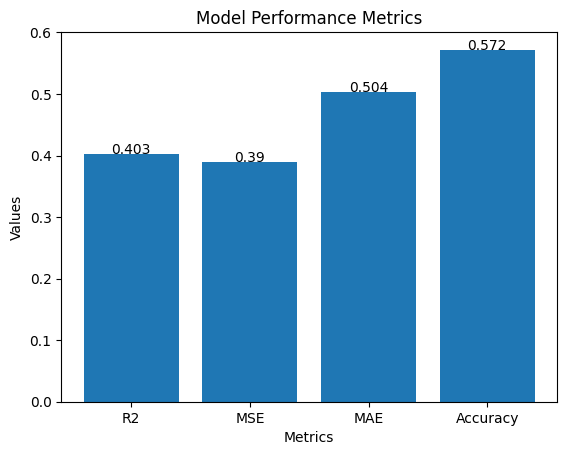


 Done!


In [20]:
def evaluate(model, x_test, y_test):
    y_pred = model.predict(x_test)


    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    y_pred_round = np.round(y_pred)
    acc = accuracy_score(y_test, y_pred_round)

    print("\n Model Performance")
    print("R2 Score:", r2)
    print("MSE:", mse)
    print("MAE:", mae)
    print("Accuracy:", acc)

    return r2, mse, mae, acc


def plot_metrics(r2, mse, mae, acc):
    metrics = ['R2', 'MSE', 'MAE', 'Accuracy']
    values = [r2, mse, mae, acc]

    plt.figure()
    plt.bar(metrics, values)

    plt.title("Model Performance Metrics")
    plt.xlabel("Metrics")
    plt.ylabel("Values")

    for i, v in enumerate(values):
        plt.text(i, v, round(v, 3), ha='center')

    plt.show()


def main():
    print(" Running Wine Quality Prediction Pipeline")

    r2, mse, mae, acc = evaluate(model, x_test, y_test)

    plot_metrics(r2, mse, mae, acc)

    print("\n Done!")


if __name__ == "__main__":
    main()

r2 should be higher    
mse should be ideally 0   
mae should be ideally 0